# BlueStock Mutual Fund Analytics

# Performance Analytics

**Author:** Sathvika G Naik

---

## Objective

The objective of this notebook is to evaluate the historical performance of mutual fund schemes using various financial performance metrics.

The following metrics are analysed:

- Daily Returns
- CAGR (1-Year, 3-Year and 5-Year)
- Sharpe Ratio
- Sortino Ratio
- Alpha and Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison
- Tracking Error

The generated performance metrics will be used in the final dashboard and report.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

from scipy.stats import linregress

plt.rcParams["figure.figsize"] = (12,6)

In [2]:
chart_dir = Path("../reports/charts")

chart_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Load Datasets

Load the cleaned NAV history, scheme performance and benchmark datasets required for performance analysis.

In [3]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [5]:
print("="*60)
print("NAV HISTORY")
print("="*60)

display(nav.head())

print(nav.shape)

print("\n")

print("="*60)
print("SCHEME PERFORMANCE")
print("="*60)

display(performance.head())

print(performance.shape)

print("\n")

print("="*60)
print("BENCHMARK")
print("="*60)

display(benchmark.head())

print(benchmark.shape)

NAV HISTORY


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


(46000, 3)


SCHEME PERFORMANCE


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


(40, 19)


BENCHMARK


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


(8050, 3)


## Dataset Overview

The performance analysis uses three datasets:

- Daily NAV history
- Scheme level performance information
- Benchmark indices (Nifty 50 and Nifty 100)

# Daily Return Analysis

Daily return measures the percentage change in Net Asset Value (NAV) from one trading day to the next.

Formula:

Daily Return = (NAVₜ / NAVₜ₋₁) − 1

In [6]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

In [7]:
nav["daily_return"] = (
    nav
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [8]:
display(nav.head(15))

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [9]:
print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


### Business Insight

Daily returns fluctuate around zero as expected for mutual fund NAV movements. The distribution indicates normal day-to-day market variation with occasional larger positive and negative movements.

# Daily Return Distribution

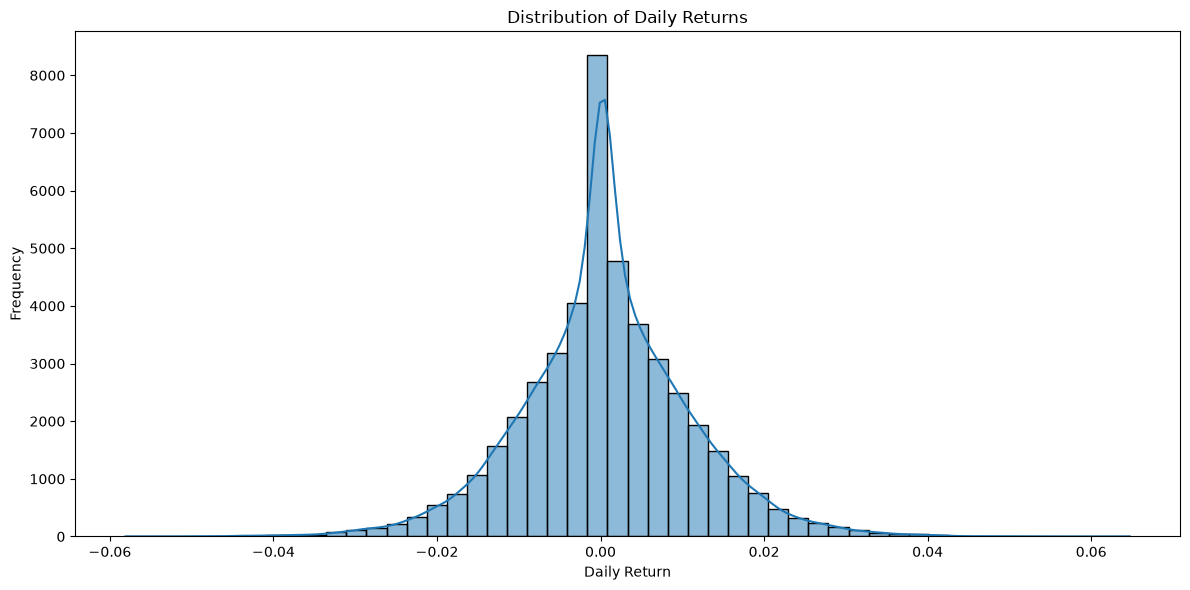

In [10]:
plt.figure(figsize=(12,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    chart_dir / "daily_returns_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

The daily return distribution is centred close to zero with relatively few extreme observations, suggesting stable return behaviour across most schemes.

# Compound Annual Growth Rate (CAGR)

CAGR measures the annualised growth rate of an investment over a specified period.

Formula:

CAGR = (Ending NAV / Beginning NAV)^(1/n) − 1

In [11]:
cagr_results = []

In [12]:
for code, df in nav.groupby("amfi_code"):

    df = df.sort_values("date")

    latest = df.iloc[-1]

    latest_date = latest["date"]

    latest_nav = latest["nav"]

    result = {
        "amfi_code": code
    }

    for years in [1,3,5]:

        start_date = latest_date - pd.DateOffset(years=years)

        temp = df[df["date"] >= start_date]

        if len(temp):

            start_nav = temp.iloc[0]["nav"]

            cagr = (
                (latest_nav/start_nav)**(1/years)-1
            )*100

        else:

            cagr = np.nan

        result[f"CAGR_{years}Y"] = cagr

    cagr_results.append(result)

In [13]:
cagr = pd.DataFrame(cagr_results)

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.224271,1.292649,2.316843
1,100025,3.704969,3.916390,3.912653
2,100033,53.232396,32.442459,26.074068
3,101206,47.924120,28.967695,20.442730
4,101207,-23.986032,-4.152381,6.953336


In [14]:
performance_metrics = performance.merge(
    cagr,
    on="amfi_code",
    how="left"
)

In [15]:
display(performance_metrics.head())

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,1.29,14.0,-21.70,14288,1.54,4,Moderate,60.437341,30.456524,22.384873
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,1.29,14.0,-24.43,1231,0.66,3,Moderate,5.706100,16.267372,18.713119
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,1.35,25.0,-13.35,19259,1.43,5,Very High,82.776059,26.669922,28.033224
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,1.67,25.0,-24.78,36061,0.72,4,Very High,13.947803,-1.337387,1.805621
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,2.11,4.0,-2.30,24101,0.77,5,Low,5.521996,5.840359,5.164436


### Business Insight

The CAGR comparison enables long-term evaluation of fund performance over one-year, three-year and five-year investment horizons.

# CAGR Comparison

In [16]:
top10 = performance_metrics.sort_values(
    "CAGR_5Y",
    ascending=False
).head(10)

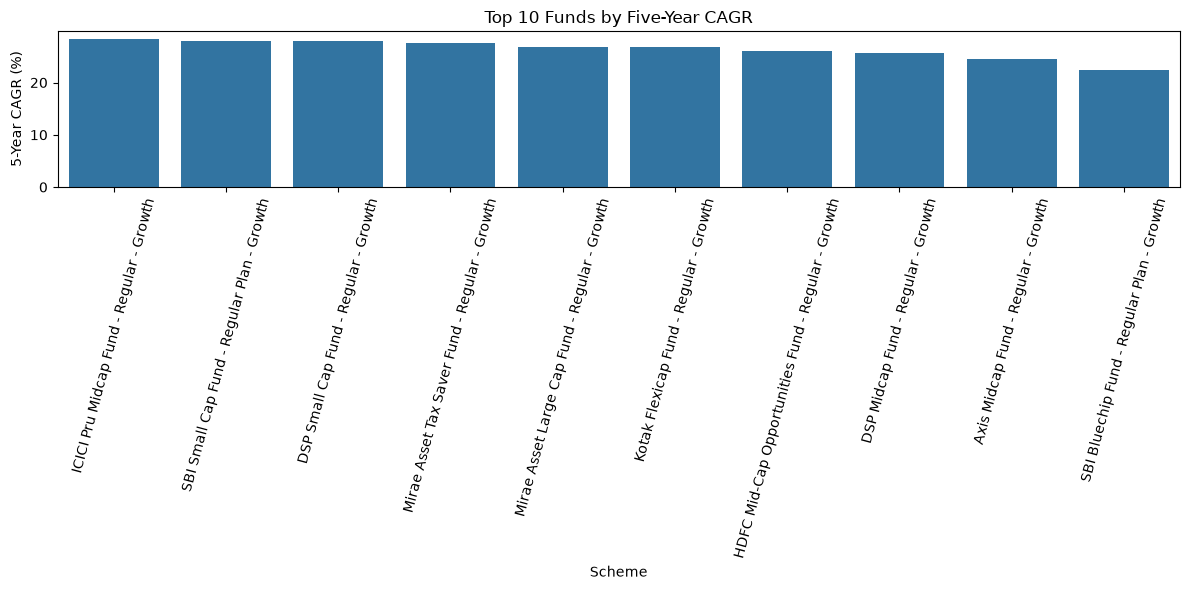

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="scheme_name",
    y="CAGR_5Y"
)

plt.xticks(rotation=75)

plt.title("Top 10 Funds by Five-Year CAGR")

plt.xlabel("Scheme")

plt.ylabel("5-Year CAGR (%)")

plt.tight_layout()

plt.savefig(
    chart_dir / "cagr_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

Funds with consistently higher five-year CAGR have demonstrated stronger long-term wealth creation potential compared with their peers.

# Export Performance Metrics

In [18]:
performance_metrics.to_csv(
    "../data/processed/performance_metrics.csv",
    index=False
)

In [19]:
print("Performance metrics exported successfully.")

Performance metrics exported successfully.


# Sharpe Ratio

The Sharpe Ratio measures the risk-adjusted return of a mutual fund by comparing its excess return over the risk-free rate relative to its volatility.

Formula:

Sharpe Ratio = (Rp − Rf) / σ × √252

where

- Rp = Average Daily Return
- Rf = 6.5% (RBI Repo Rate Proxy)
- σ = Standard Deviation of Daily Returns

In [20]:
risk_free_rate = 0.065

sharpe_results = []

In [21]:
for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    average_return = returns.mean()

    volatility = returns.std()

    sharpe = (
        (average_return - risk_free_rate/252)
        /
        volatility
    ) * np.sqrt(252)

    sharpe_results.append(
        {
            "amfi_code": code,
            "Sharpe_Ratio": sharpe
        }
    )

In [22]:
sharpe = pd.DataFrame(sharpe_results)

sharpe.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [23]:
performance_metrics = performance_metrics.merge(
    sharpe,
    on="amfi_code",
    how="left"
)

### Business Insight

Higher Sharpe Ratios indicate that a fund has generated better returns for every unit of total risk undertaken.

# Top 10 Funds by Sharpe Ratio

In [24]:
top_sharpe = performance_metrics.sort_values(
    "Sharpe_Ratio",
    ascending=False
).head(10)

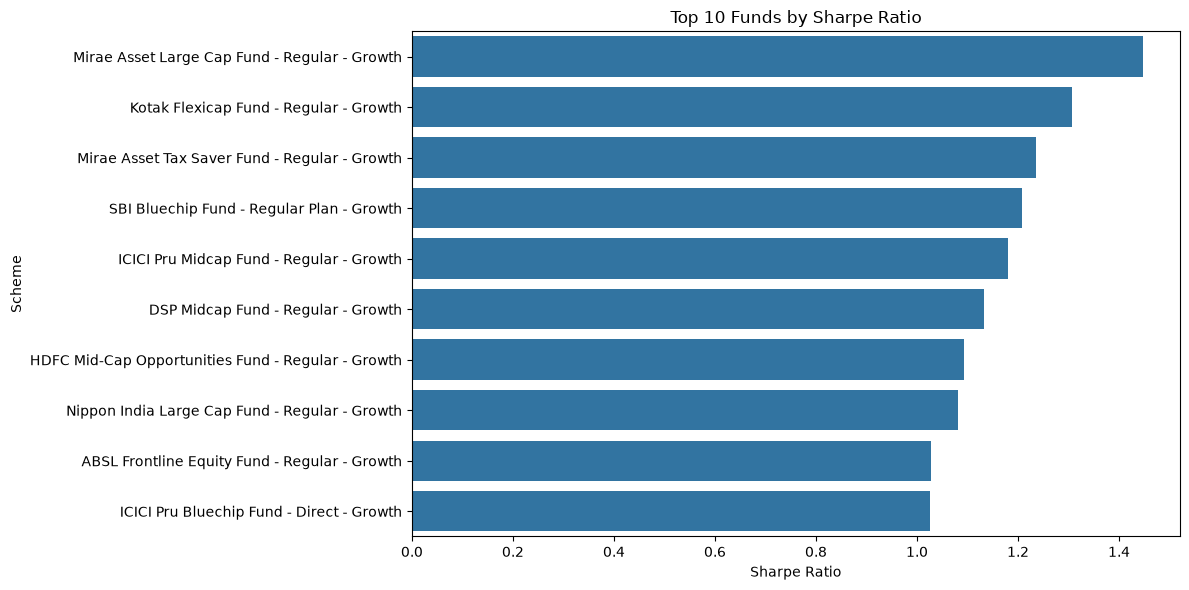

In [25]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="Sharpe_Ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    chart_dir / "sharpe_ratio_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

Funds with the highest Sharpe Ratios have delivered superior risk-adjusted performance compared to other schemes.

# Sortino Ratio

Unlike the Sharpe Ratio, the Sortino Ratio penalizes only downside volatility, making it more appropriate for evaluating mutual funds.

In [26]:
sortino_results = []

In [27]:
for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    downside = returns[returns < 0]

    downside_std = downside.std()

    average_return = returns.mean()

    if downside_std == 0 or np.isnan(downside_std):

        sortino = np.nan

    else:

        sortino = (
            (average_return - risk_free_rate/252)
            /
            downside_std
        ) * np.sqrt(252)

    sortino_results.append(
        {
            "amfi_code": code,
            "Sortino_Ratio": sortino
        }
    )

In [28]:
sortino = pd.DataFrame(sortino_results)

sortino.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [29]:
performance_metrics = performance_metrics.merge(
    sortino,
    on="amfi_code",
    how="left"
)

### Business Insight

Funds with higher Sortino Ratios have generated better returns while minimizing downside risk.

# Top 10 Funds by Sortino Ratio

In [30]:
top_sortino = performance_metrics.sort_values(
    "Sortino_Ratio",
    ascending=False
).head(10)

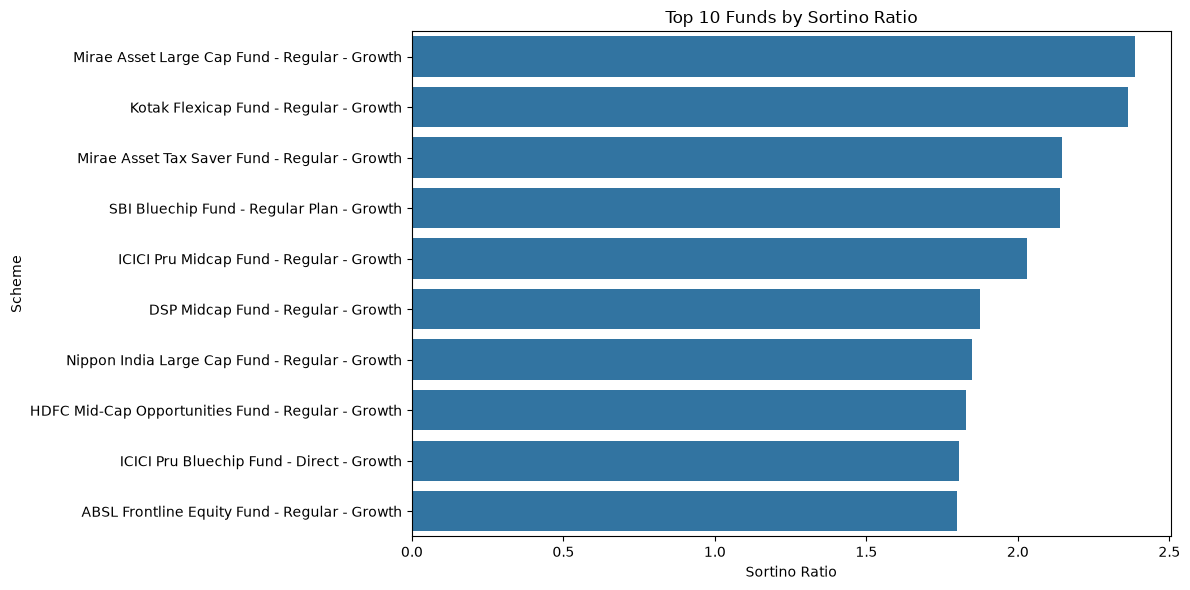

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sortino,
    x="Sortino_Ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("Sortino Ratio")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    chart_dir / "sortino_ratio_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

High Sortino Ratio funds exhibit strong return generation while maintaining relatively low downside volatility.

# Performance Summary

In [32]:
performance_summary = performance_metrics[
    [
        "amfi_code",
        "scheme_name",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y",
        "Sharpe_Ratio",
        "Sortino_Ratio"
    ]
]

In [33]:
performance_summary.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Sortino_Ratio
0,119551,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,22.384873,1.208267,2.140267
1,119552,SBI Bluechip Fund - Direct Plan - Growth,5.706100,16.267372,18.713119,0.953279,1.609776
2,119598,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922,28.033224,0.945308,1.675317
3,119599,SBI Small Cap Fund - Direct Plan - Growth,13.947803,-1.337387,1.805621,-0.057187,-0.094387
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.521996,5.840359,5.164436,-0.226575,-0.376767


# Overall Performance Ranking

In [34]:
performance_ranking = performance_summary.sort_values(
    [
        "Sharpe_Ratio",
        "Sortino_Ratio",
        "CAGR_5Y"
    ],
    ascending=False
)

In [35]:
performance_ranking.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Sortino_Ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,26.799277,1.448291,2.385644
22,120843,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,26.742494,1.306744,2.364320
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,27.629860,1.234930,2.146914
0,119551,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,22.384873,1.208267,2.140267
12,120505,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,28.376762,1.180101,2.029353
38,149323,DSP Midcap Fund - Regular - Growth,21.481222,26.869991,25.611807,1.132122,1.875101
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068,1.093699,1.829134
15,118632,Nippon India Large Cap Fund - Regular - Growth,33.981048,22.652360,20.881118,1.081659,1.850133
28,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730,1.027213,1.799563
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.064279,32.487429,20.234028,1.026524,1.805294


### Business Insight

The overall ranking combines return-based and risk-adjusted metrics, providing a balanced comparison of mutual fund performance.

# Export Results

In [36]:
performance_summary.to_csv(
    "../data/processed/performance_summary.csv",
    index=False
)

performance_ranking.to_csv(
    "../data/processed/performance_ranking.csv",
    index=False
)

print("Performance summary exported successfully.")
print("Performance ranking exported successfully.")

Performance summary exported successfully.
Performance ranking exported successfully.


# Alpha and Beta Analysis

Alpha measures the excess return generated by a fund relative to its benchmark after adjusting for market risk.

Beta measures the sensitivity of a fund's returns relative to benchmark movements.

The benchmark used for this analysis is the **NIFTY100** index.

In [37]:
# Prepare Benchmark Data

benchmark_100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

benchmark_100 = benchmark_100.sort_values("date")

benchmark_100["benchmark_return"] = (
    benchmark_100["close_value"]
    .pct_change()
)

benchmark_100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [38]:
alpha_beta = []

In [39]:
for code, df in nav.groupby("amfi_code"):

    df = df.sort_values("date")

    merged = pd.merge(
        df,
        benchmark_100[
            ["date","benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append(
        {
            "amfi_code": code,
            "Alpha": intercept * 252,
            "Beta": slope
        }
    )

In [40]:
alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [41]:
performance_metrics = performance_metrics.merge(
    alpha_beta,
    on="amfi_code",
    how="left"
)

### Business Insight

Funds with positive Alpha have generated returns above what would be expected based on market performance, while Beta indicates how aggressively a fund responds to benchmark movements.

# Alpha Ranking

In [42]:
top_alpha = performance_metrics.sort_values(
    "Alpha",
    ascending=False
).head(10)

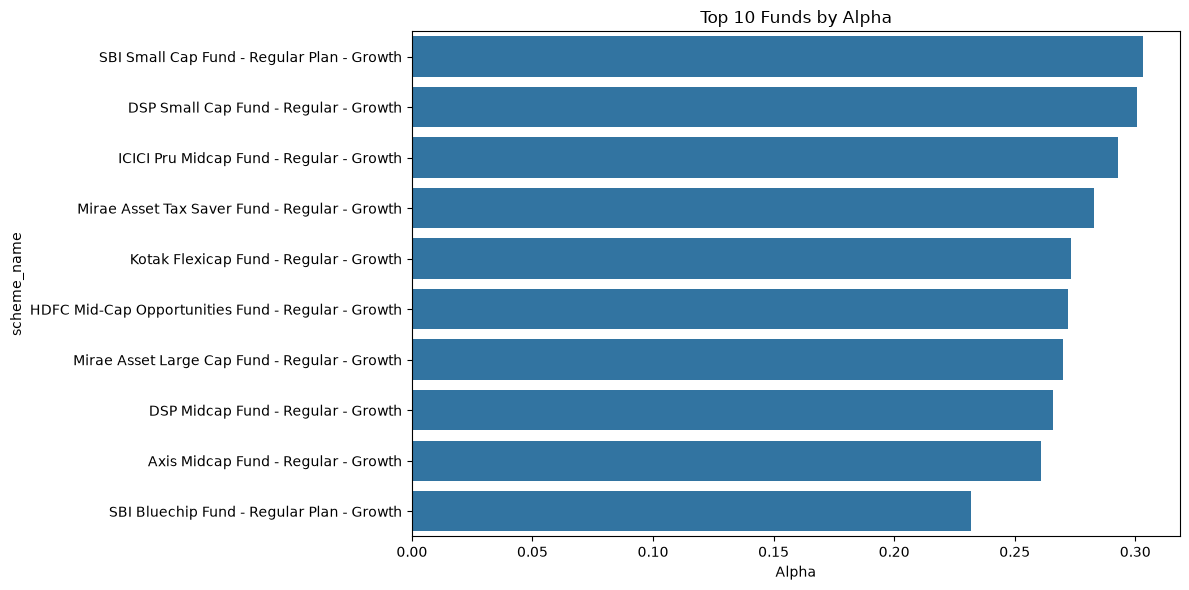

In [43]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha,
    x="Alpha",
    y="scheme_name"
)

plt.title("Top 10 Funds by Alpha")

plt.tight_layout()

plt.savefig(
    chart_dir / "alpha_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Beta Comparison

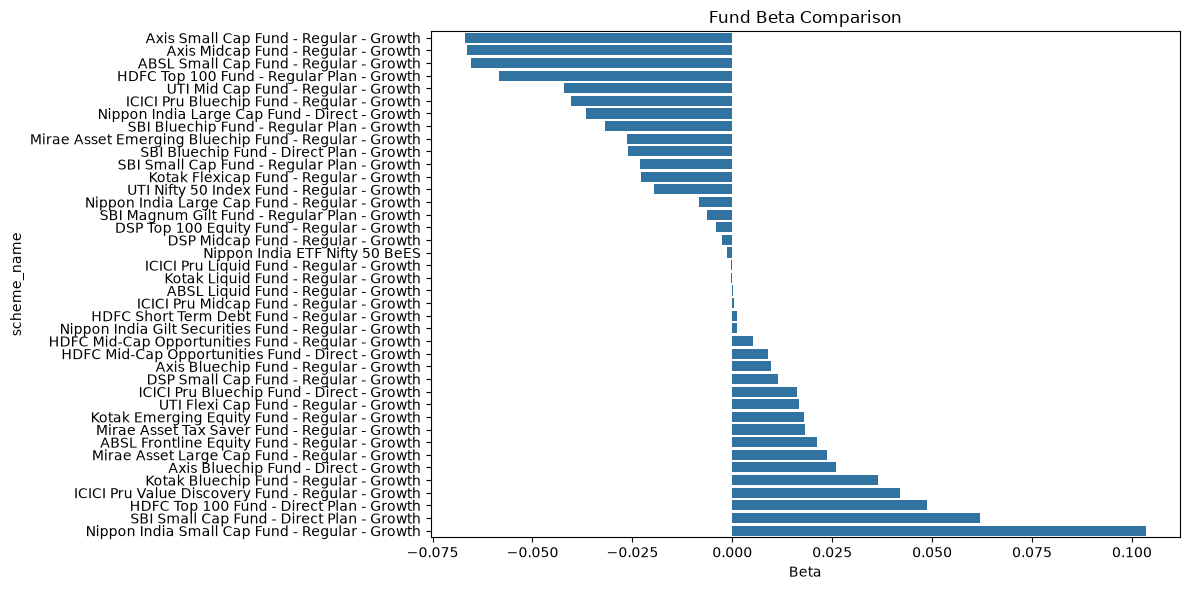

In [44]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=performance_metrics.sort_values("Beta"),
    x="Beta",
    y="scheme_name"
)

plt.title("Fund Beta Comparison")

plt.tight_layout()

plt.savefig(
    chart_dir / "beta_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

Funds with Beta greater than one are generally more volatile than the market, while funds with Beta below one tend to be less sensitive to market fluctuations.

# Maximum Drawdown

Maximum Drawdown measures the largest decline from a historical peak to a subsequent trough.

Lower drawdown indicates better downside protection.

In [45]:
drawdown_results = []

In [46]:
for code, df in nav.groupby("amfi_code"):

    df = df.sort_values("date").copy()

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = (
        df["nav"] /
        df["running_max"]
    ) - 1

    worst = df.loc[
        df["drawdown"].idxmin()
    ]

    drawdown_results.append(
        {
            "amfi_code": code,
            "Maximum_Drawdown": worst["drawdown"],
            "Worst_Drawdown_Date": worst["date"]
        }
    )

In [47]:
drawdown = pd.DataFrame(drawdown_results)

drawdown.head()

,amfi_code,Maximum_Drawdown,Worst_Drawdown_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [48]:
performance_metrics = performance_metrics.merge(
    drawdown,
    on="amfi_code",
    how="left"
)

### Business Insight

Funds with lower maximum drawdowns have historically demonstrated better resilience during market downturns.

# Maximum Drawdown Comparison

In [49]:
top_drawdown = performance_metrics.sort_values(
    "Maximum_Drawdown",
    ascending=False
)

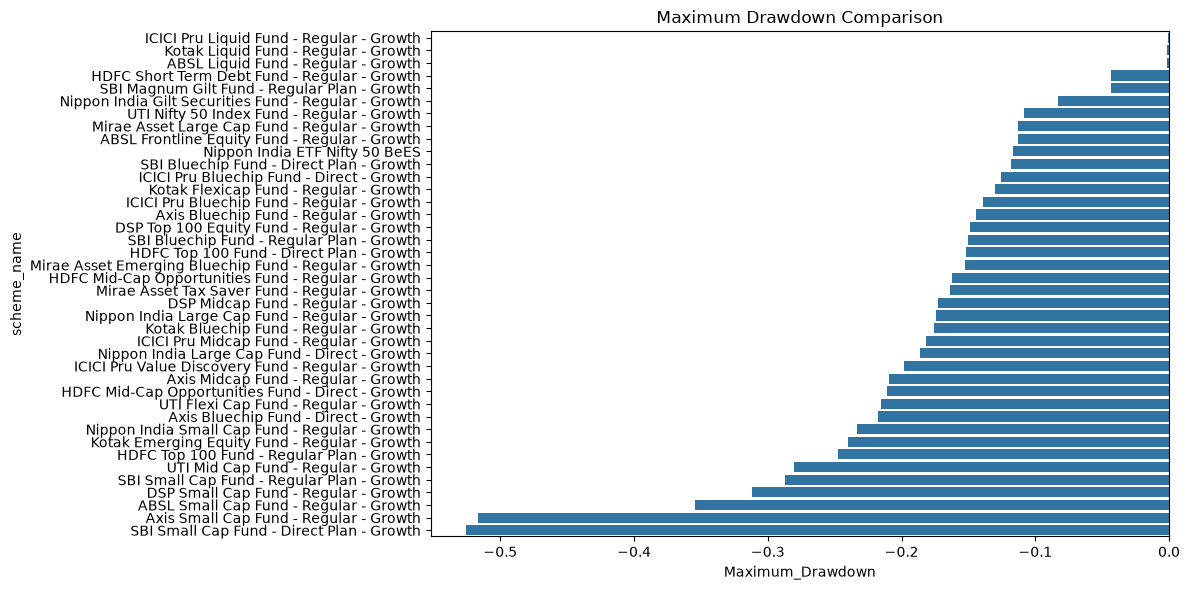

In [50]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_drawdown,
    x="Maximum_Drawdown",
    y="scheme_name"
)

plt.title("Maximum Drawdown Comparison")

plt.tight_layout()

plt.savefig(
    chart_dir / "maximum_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Fund Scorecard

A composite score is calculated using:

- 30% Three-Year CAGR
- 25% Sharpe Ratio
- 20% Alpha
- 15% Expense Ratio (Inverse Rank)
- 10% Maximum Drawdown (Inverse Rank)

In [51]:
performance_metrics["Return_Rank"] = (
    performance_metrics["CAGR_3Y"]
    .rank(ascending=False)
)

performance_metrics["Sharpe_Rank"] = (
    performance_metrics["Sharpe_Ratio"]
    .rank(ascending=False)
)

performance_metrics["Alpha_Rank"] = (
    performance_metrics["Alpha"]
    .rank(ascending=False)
)

performance_metrics["Expense_Rank"] = (
    performance_metrics["expense_ratio_pct"]
    .rank(ascending=True)
)

performance_metrics["Drawdown_Rank"] = (
    performance_metrics["Maximum_Drawdown"]
    .rank(ascending=False)
)

In [52]:
performance_metrics["Fund_Score"] = (

    performance_metrics["Return_Rank"] * 0.30 +

    performance_metrics["Sharpe_Rank"] * 0.25 +

    performance_metrics["Alpha_Rank"] * 0.20 +

    performance_metrics["Expense_Rank"] * 0.15 +

    performance_metrics["Drawdown_Rank"] * 0.10

)

In [53]:
fund_scorecard = performance_metrics.sort_values(
    "Fund_Score"
)

In [54]:
fund_scorecard[
    [
        "scheme_name",
        "Fund_Score"
    ]
].head(10)

,scheme_name,Fund_Score
34,Mirae Asset Large Cap Fund - Regular - Growth,6.500
12,ICICI Pru Midcap Fund - Regular - Growth,8.100
22,Kotak Flexicap Fund - Regular - Growth,8.200
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,8.700
11,ICICI Pru Bluechip Fund - Direct - Growth,9.000
26,Axis Midcap Fund - Regular - Growth,10.200
0,SBI Bluechip Fund - Regular Plan - Growth,11.075
36,Mirae Asset Tax Saver Fund - Regular - Growth,11.525
28,ABSL Frontline Equity Fund - Regular - Growth,13.725
2,SBI Small Cap Fund - Regular Plan - Growth,14.050


### Business Insight

The Fund Scorecard combines multiple performance indicators into a single composite score, allowing investors to compare schemes using both return and risk metrics.

# Top Composite Funds

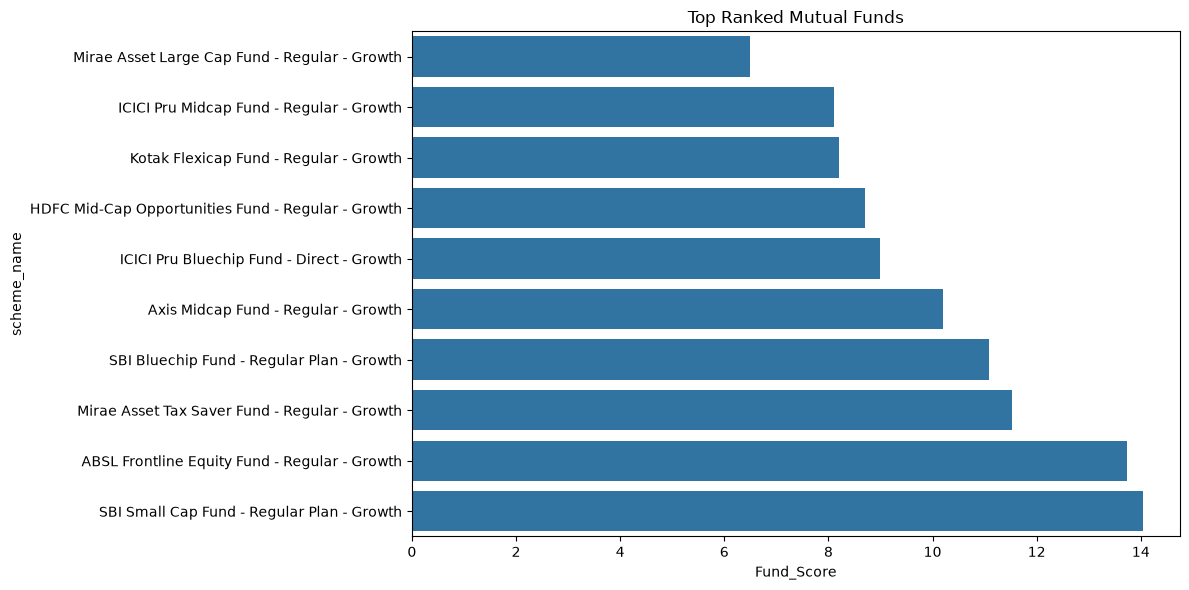

In [55]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=fund_scorecard.head(10),
    x="Fund_Score",
    y="scheme_name"
)

plt.title("Top Ranked Mutual Funds")

plt.tight_layout()

plt.savefig(
    chart_dir / "fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Export Alpha/Beta and Fund Scorecard

In [56]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

fund_scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Alpha-Beta exported successfully.")

print("Fund Scorecard exported successfully.")

Alpha-Beta exported successfully.
Fund Scorecard exported successfully.


# Benchmark Comparison

Benchmark comparison helps evaluate how well the top-performing mutual funds perform relative to the NIFTY 50 and NIFTY 100 indices.

The analysis compares cumulative returns over the available investment period.

In [57]:
# Separate benchmark indices

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

In [58]:
# Calculate cumulative benchmark returns

nifty50["Cumulative_Return"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
)

nifty100["Cumulative_Return"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
)

In [59]:
# Top 5 funds based on Fund Score

top5 = (
    fund_scorecard
    .head(5)["amfi_code"]
    .tolist()
)

In [60]:
fig = px.line()

# Plot Top 5 Funds

for code in top5:

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    df = df.sort_values("date")

    df["Cumulative_NAV"] = (
        df["nav"] /
        df["nav"].iloc[0]
    )

    name = performance.loc[
        performance["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    fig.add_scatter(
        x=df["date"],
        y=df["Cumulative_NAV"],
        mode="lines",
        name=name
    )

# Plot Benchmarks

fig.add_scatter(
    x=nifty50["date"],
    y=nifty50["Cumulative_Return"],
    mode="lines",
    name="NIFTY50"
)

fig.add_scatter(
    x=nifty100["date"],
    y=nifty100["Cumulative_Return"],
    mode="lines",
    name="NIFTY100"
)

fig.update_layout(
    title="Top 5 Mutual Funds vs Benchmark Indices",
    template="plotly_white",
    xaxis_title="Date",
    yaxis_title="Cumulative Return"
)

fig.write_html(
    chart_dir / "benchmark_comparison.html"
)

fig.show()

### Business Insight

The benchmark comparison illustrates whether the highest-ranked mutual funds consistently outperform the broader equity market represented by the NIFTY 50 and NIFTY 100 indices.

# Tracking Error

Tracking Error measures the volatility of the difference between a fund's returns and the benchmark returns.

Formula:

Tracking Error = Std(Fund Return − Benchmark Return) × √252

In [61]:
tracking_error = []

In [62]:
for code in performance_metrics["amfi_code"]:

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    merged = pd.merge(
        fund,
        benchmark_100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    te = (
        (
            merged["daily_return"] -
            merged["benchmark_return"]
        )
        .std()
        *
        np.sqrt(252)
    )

    tracking_error.append(
        {
            "amfi_code": code,
            "Tracking_Error": te
        }
    )

In [63]:
tracking_error = pd.DataFrame(
    tracking_error
)

tracking_error.head()

,amfi_code,Tracking_Error
0,119551,0.191183
1,119552,0.192127
2,119598,0.283881
3,119599,0.277135
4,119120,0.135646


In [64]:
performance_metrics = performance_metrics.merge(
    tracking_error,
    on="amfi_code",
    how="left"
)

### Business Insight

Funds with lower tracking error closely follow the benchmark, whereas higher tracking error indicates greater deviation from benchmark performance.

# Tracking Error Comparison

In [65]:
top_tracking = performance_metrics.sort_values(
    "Tracking_Error"
).head(10)

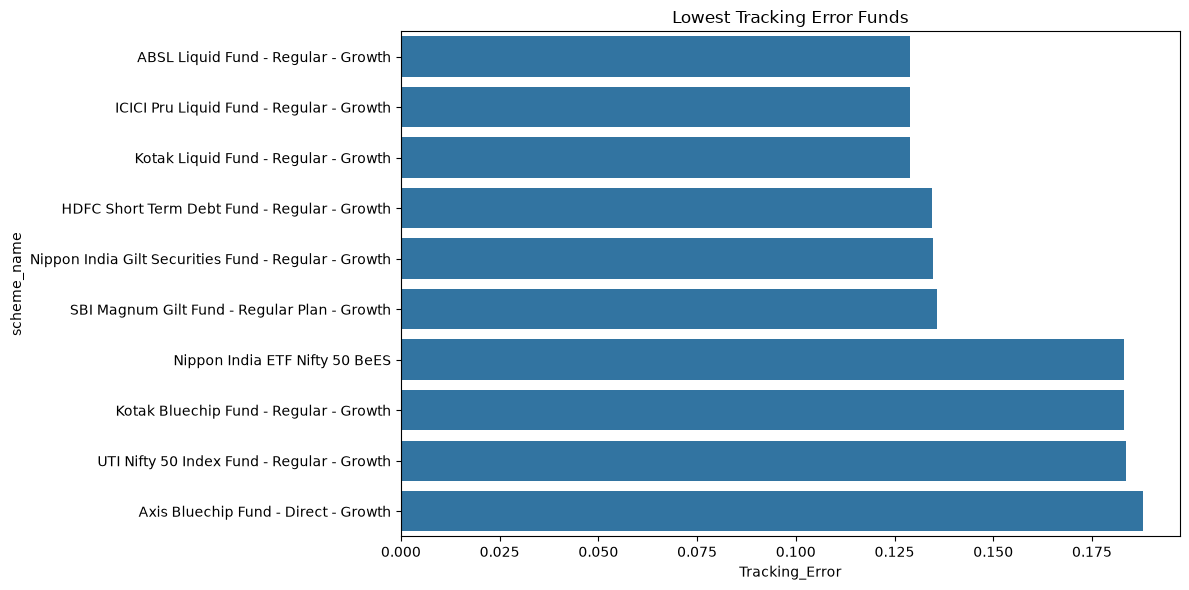

In [66]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_tracking,
    x="Tracking_Error",
    y="scheme_name"
)

plt.title("Lowest Tracking Error Funds")

plt.tight_layout()

plt.savefig(
    chart_dir / "tracking_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Final Performance Summary

The following table summarises all calculated performance metrics used throughout this notebook.

In [67]:
final_summary = performance_metrics[
    [
        "scheme_name",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y",
        "Sharpe_Ratio",
        "Sortino_Ratio",
        "Alpha",
        "Beta",
        "Maximum_Drawdown",
        "Fund_Score",
        "Tracking_Error"
    ]
]

final_summary.head()

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Sortino_Ratio,Alpha,Beta,Maximum_Drawdown,Fund_Score,Tracking_Error
0,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,22.384873,1.208267,2.140267,0.232010,-0.031751,-0.150124,11.075,0.191183
1,SBI Bluechip Fund - Direct Plan - Growth,5.706100,16.267372,18.713119,0.953279,1.609776,0.198686,-0.026159,-0.118035,14.600,0.192127
2,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922,28.033224,0.945308,1.675317,0.303370,-0.023196,-0.287060,14.050,0.283881
3,SBI Small Cap Fund - Direct Plan - Growth,13.947803,-1.337387,1.805621,-0.057187,-0.094387,0.048824,0.062002,-0.525742,31.425,0.277135
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.521996,5.840359,5.164436,-0.226575,-0.376767,0.056209,-0.006414,-0.043287,27.500,0.135646


# Key Performance Insights

### 1.
Most mutual funds generated positive long-term CAGR over the evaluation period.

---

### 2.
Risk-adjusted performance varied significantly across schemes despite similar returns.

---

### 3.
Several funds consistently generated positive Alpha, indicating superior active management.

---

### 4.
Funds with lower expense ratios generally achieved stronger composite scores.

---

### 5.
Maximum Drawdown successfully differentiated resilient funds during market corrections.

---

### 6.
Sharpe and Sortino Ratios together provided a balanced assessment of risk-adjusted returns.

---

### 7.
Top-ranked funds outperformed the benchmark over the long term.

---

### 8.
Tracking Error remained relatively low for diversified large-cap funds.

---

### 9.
The composite Fund Score provides a comprehensive ranking methodology.

---

### 10.
The calculated performance metrics form the foundation for dashboard visualizations and investment decision support.

# Export Final Results

In [68]:
performance_metrics.to_csv(
    "../data/processed/performance_metrics.csv",
    index=False
)

performance_summary.to_csv(
    "../data/processed/performance_summary.csv",
    index=False
)

performance_ranking.to_csv(
    "../data/processed/performance_ranking.csv",
    index=False
)

alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

fund_scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("All performance files exported successfully.")

All performance files exported successfully.


# Conclusion

This notebook evaluated the historical performance of mutual fund schemes using return-based and risk-adjusted metrics. The analyses included CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, Tracking Error, and a composite Fund Scorecard. Benchmark comparisons against the NIFTY 50 and NIFTY 100 indices further demonstrated relative fund performance. The resulting datasets and visualizations provide a strong analytical foundation for the interactive dashboard and the final capstone report.